# h05_sub1 tiled facies inference

Run the style-matched conditional diffusion model on the irregular h05 RMS survey. Missing survey cells and partial border tiles are filled only to provide convolution context; predictions are retained exclusively at observed h05 cells.

The default settings run a small smoke test. Set `RUN_FULL_MAP = True` in Cell 1 to process every valid 64 x 64 tile. Full-map progress is checkpointed and can be resumed.

In [1]:
# 1. Load saved h05 inference results and the RMS survey
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

repo_root = Path.cwd().resolve()
if not (repo_root / "diffsim").exists():
    candidate = repo_root.parent
    if (candidate / "diffsim").exists():
        os.chdir(candidate)
        repo_root = candidate

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

STYLE_MATCHING_DIR = repo_root / "style-matching"
if str(STYLE_MATCHING_DIR) not in sys.path:
    sys.path.insert(0, str(STYLE_MATCHING_DIR))

from arthit_infer import load_h05_grid, subsample_grid

RUN_TIMESTAMP = "20260818_102941"
OUTPUT_DIR = Path("/mnt/sda_data/tharitt/diffsim/results") / f"arthit_inference_{RUN_TIMESTAMP}"

SUBSAMPLE_FACTOR=4
RESULT_PATH = OUTPUT_DIR / f"arthit_inference_full_samples2_steps100_eta0_sub{SUBSAMPLE_FACTOR}.npz"
H05_PATH = repo_root / "style-matching" / "h05_sub9"


if not RESULT_PATH.is_file():
    raise FileNotFoundError(f"Saved inference result not found: {RESULT_PATH}")
if not H05_PATH.is_file():
    raise FileNotFoundError(f"h05 input file not found: {H05_PATH}")

with np.load(RESULT_PATH) as saved:
    probabilities = saved["probabilities"]
    most_likely = saved["most_likely"]
    row_min = int(saved["row_min"])
    col_min = int(saved["col_min"])
    x_affine = saved["x_affine"]
    y_affine = saved["y_affine"]
    facies_names = [str(name) for name in saved["facies_names"]]

full_rms_grid, full_georef = load_h05_grid(H05_PATH)
rms_grid, georef = subsample_grid(full_rms_grid, full_georef, SUBSAMPLE_FACTOR)

if rms_grid.shape != most_likely.shape:
    raise ValueError(
        f"Subsampled RMS shape {rms_grid.shape} does not match prediction shape {most_likely.shape}; "
        "check SUBSAMPLE_FACTOR."
    )

covered = most_likely >= 0
print(f"Loaded: {RESULT_PATH}")
print(f"Full-resolution RMS shape: {full_rms_grid.shape}")
print(f"Subsampled RMS shape: {rms_grid.shape} (factor {SUBSAMPLE_FACTOR})")
print(f"Most-likely map shape: {most_likely.shape}")
print(f"Probability map shape: {probabilities.shape}")
print(f"Covered cells: {covered.sum():,}")
print("Facies counts:", dict(zip(*np.unique(most_likely[covered], return_counts=True))))


/mnt/sda_data/tharitt/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo_root = /home/tharitt/working/DiffSim
=== FILE PARAMS:===
RUN_TIMESTAMP  : 20260818_102941
CONFIG_PATH    : /mnt/sda_data/tharitt/diffsim/model/case1_flumy_conditional/20260818_102941/config.json
CHECKPOINT_PATH: /mnt/sda_data/tharitt/diffsim/model/case1_flumy_conditional/20260818_102941/best_model.pth
H05_PATH       : /home/tharitt/working/DiffSim/style-matching/h05_sub9
OUTPUT_DIR     : /mnt/sda_data/tharitt/diffsim/results/arthit_inference_20260818_102941
DEVICE         : cuda
BATCH_SIZE     : 16
===INFERENCE PARAMS===
SUBSAMPLE      : 4
N_SAMPLES      : 2
DDIM_STEPS     : 100
ETA            : 0.0
Mode           : full h05 map
Loaded: /mnt/sda_data/tharitt/diffsim/results/arthit_inference_20260818_102941/arthit_inference_full_samples2_steps100_eta0_sub4.npz
Full-resolution RMS shape: (5772, 1668)
Subsampled RMS shape: (1443, 417) (factor 4)
Most-likely map shape: (1443, 417)
Probability map shape: (3, 1443, 417)
Covered cells: 369,237
Facies counts: {np.int8(0): np.int64(240237)

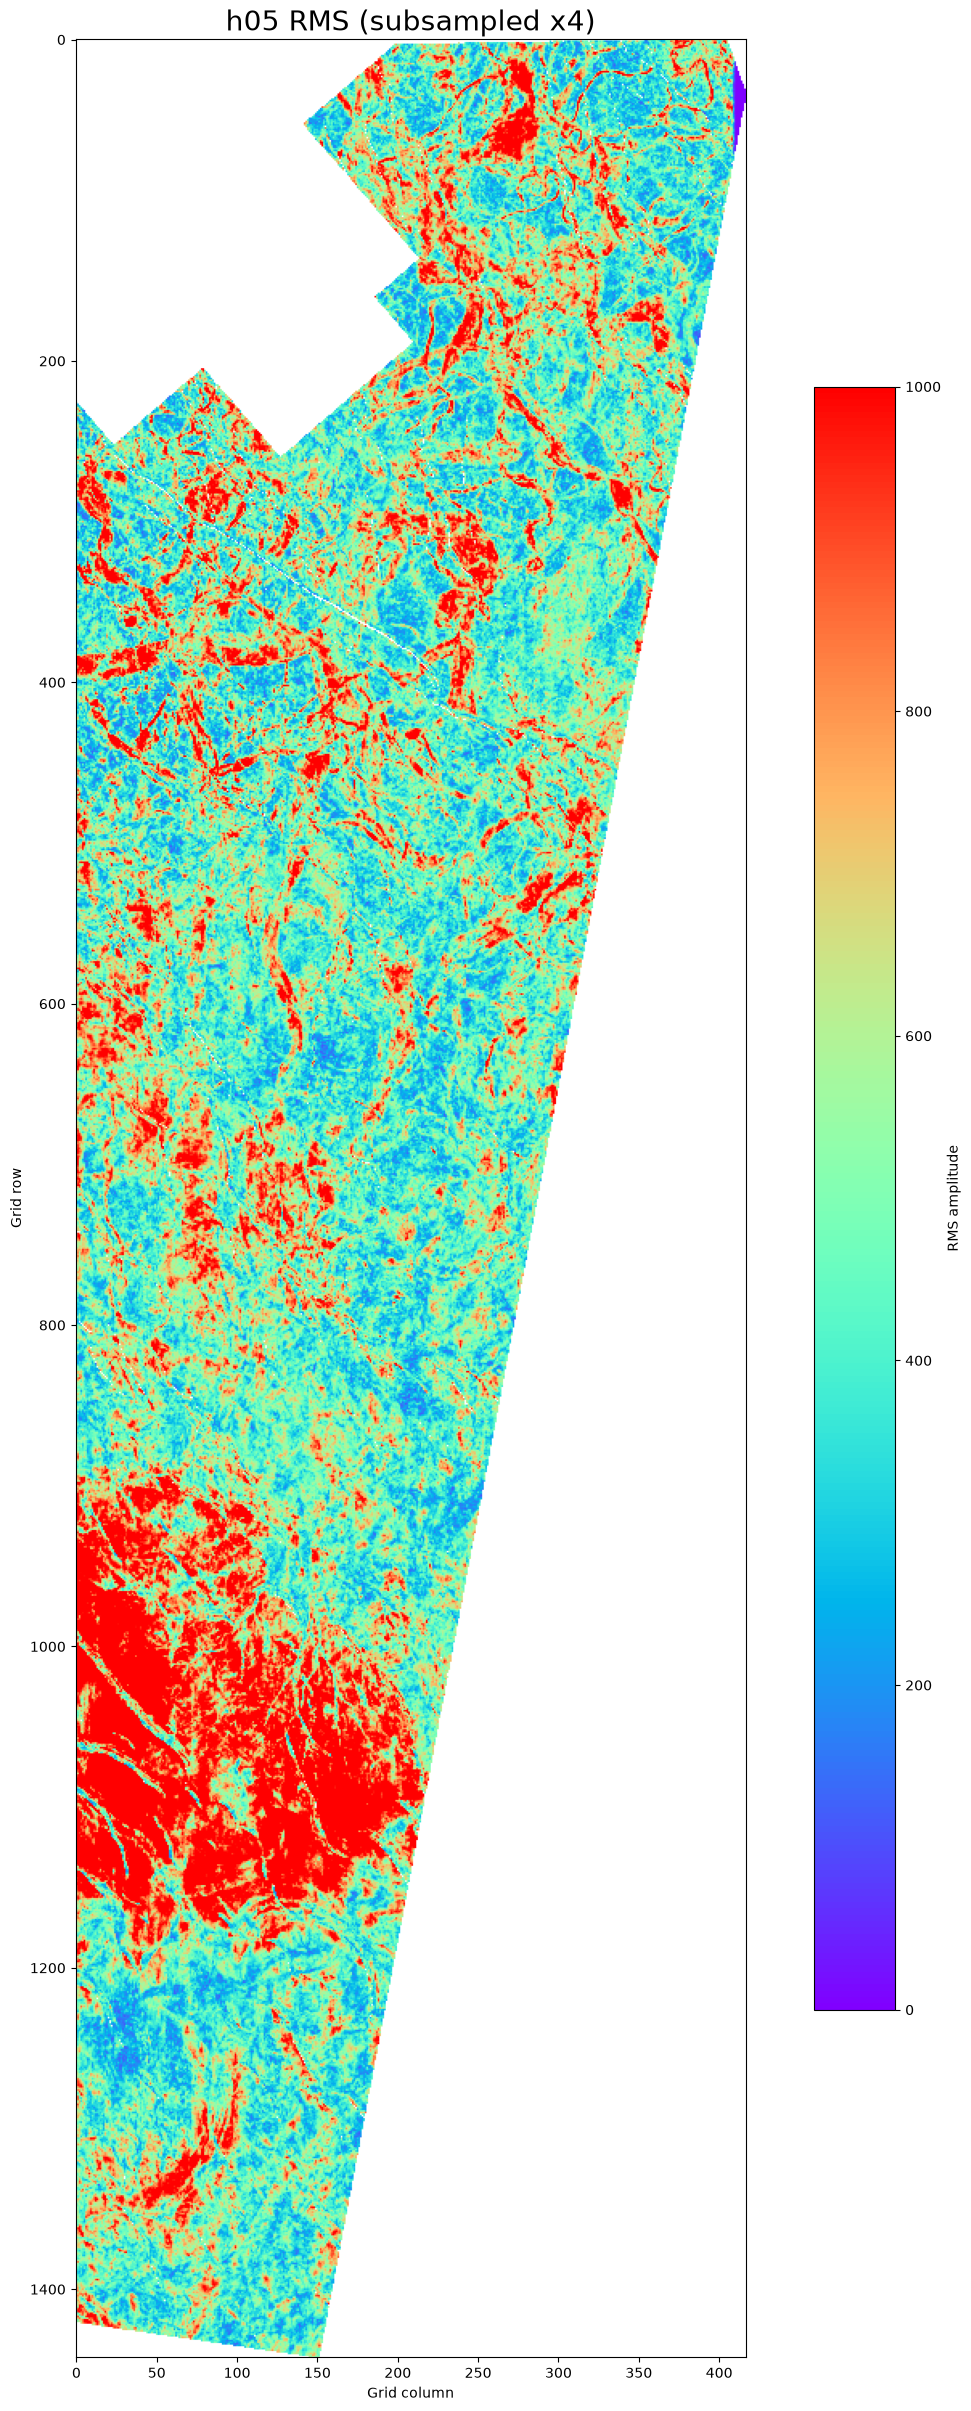

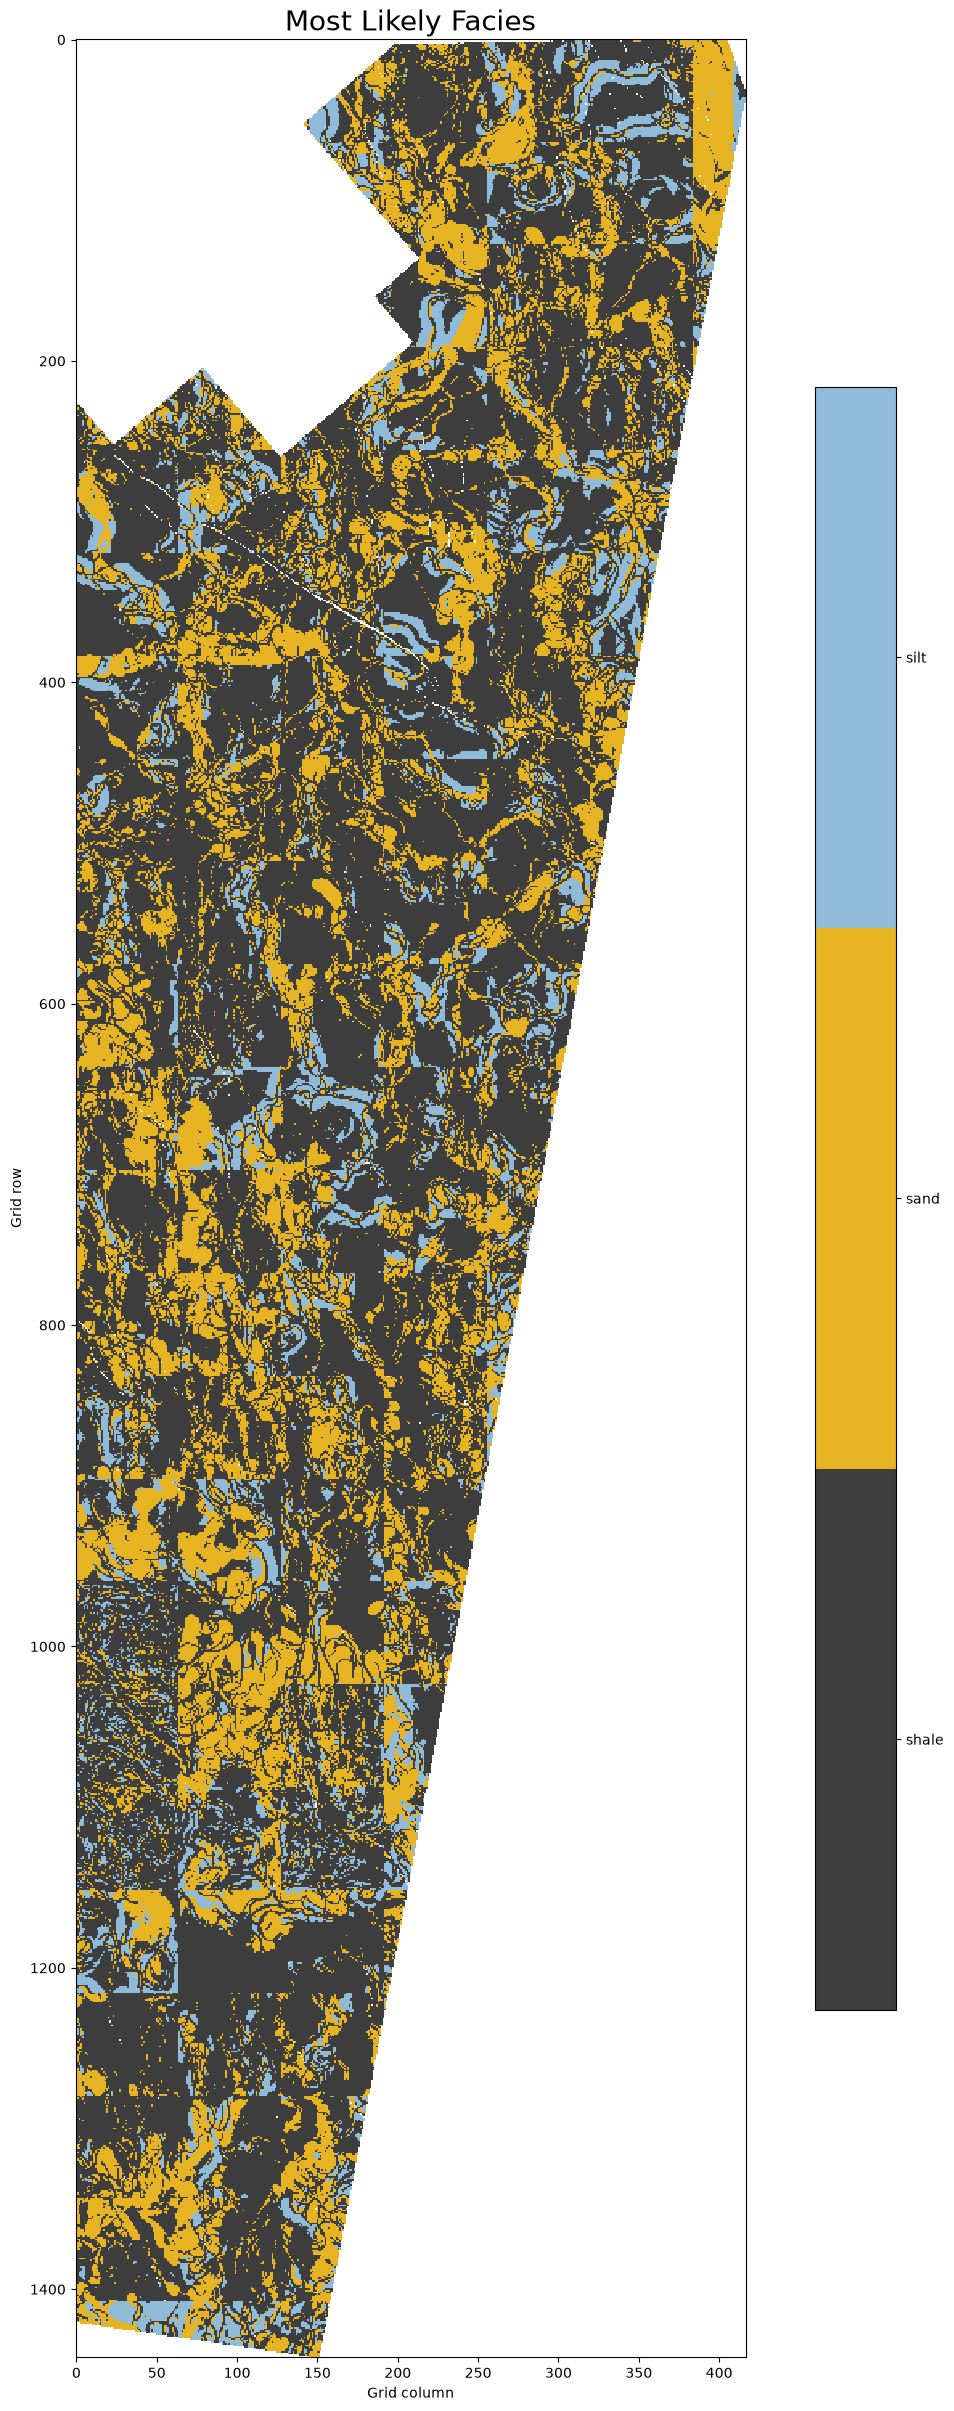

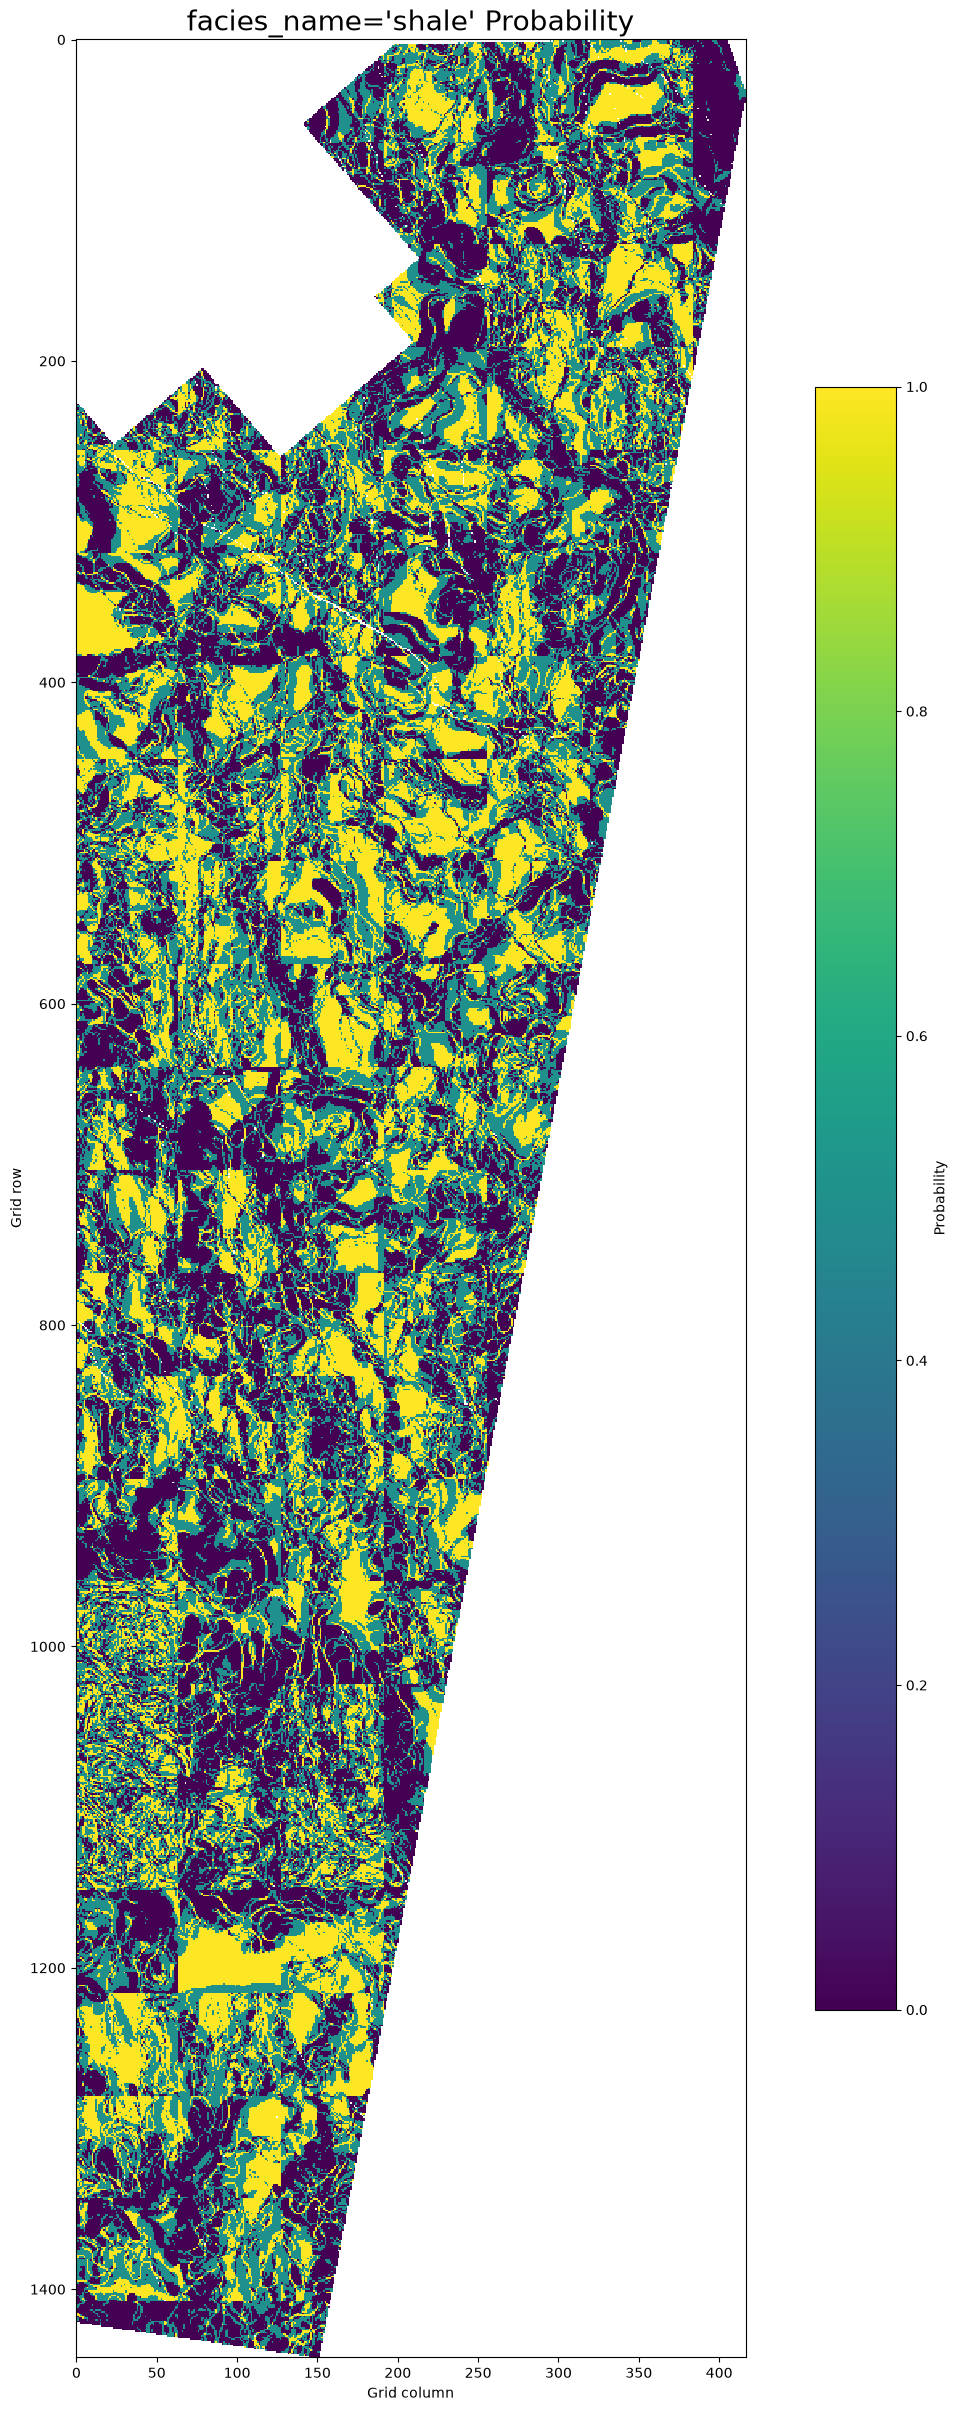

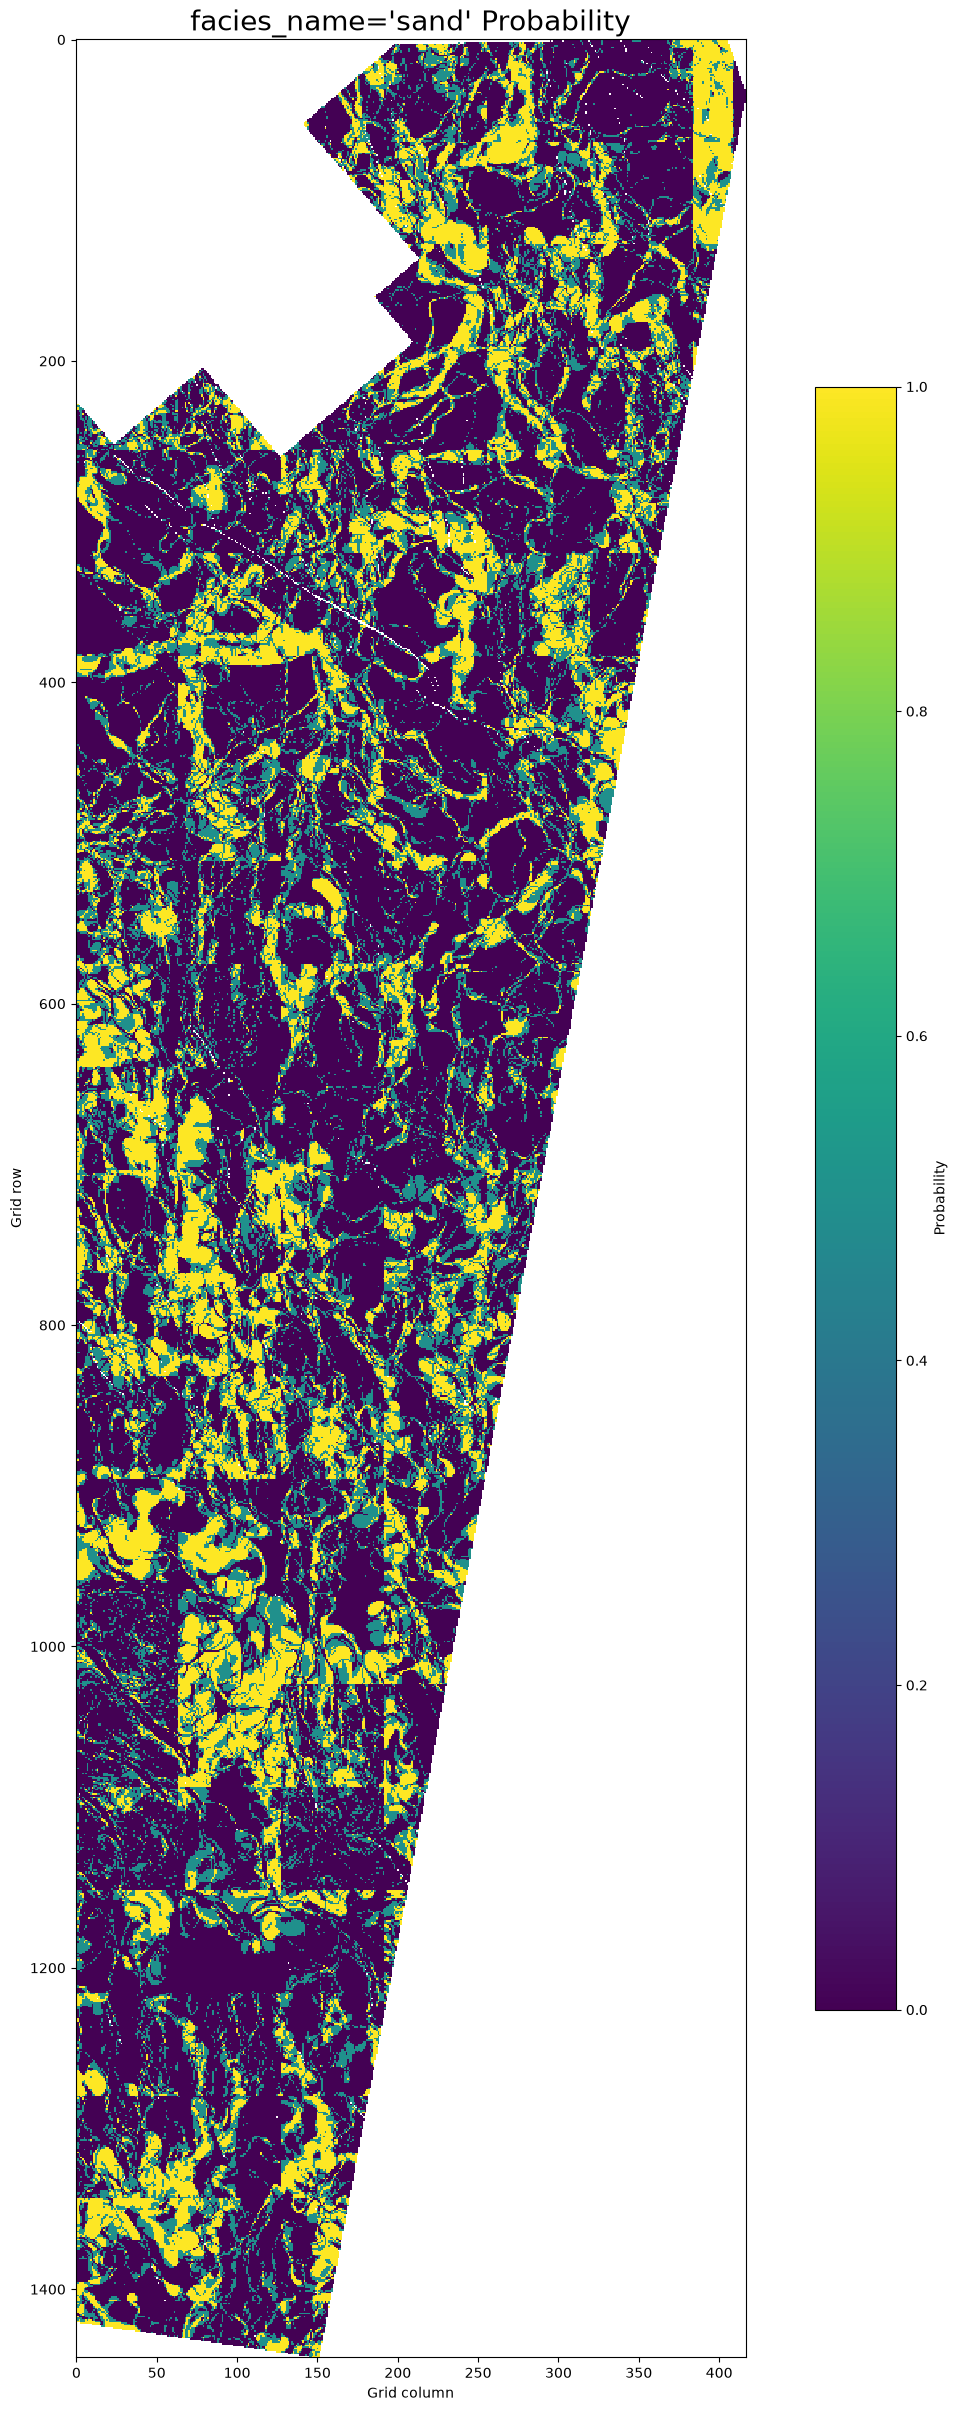

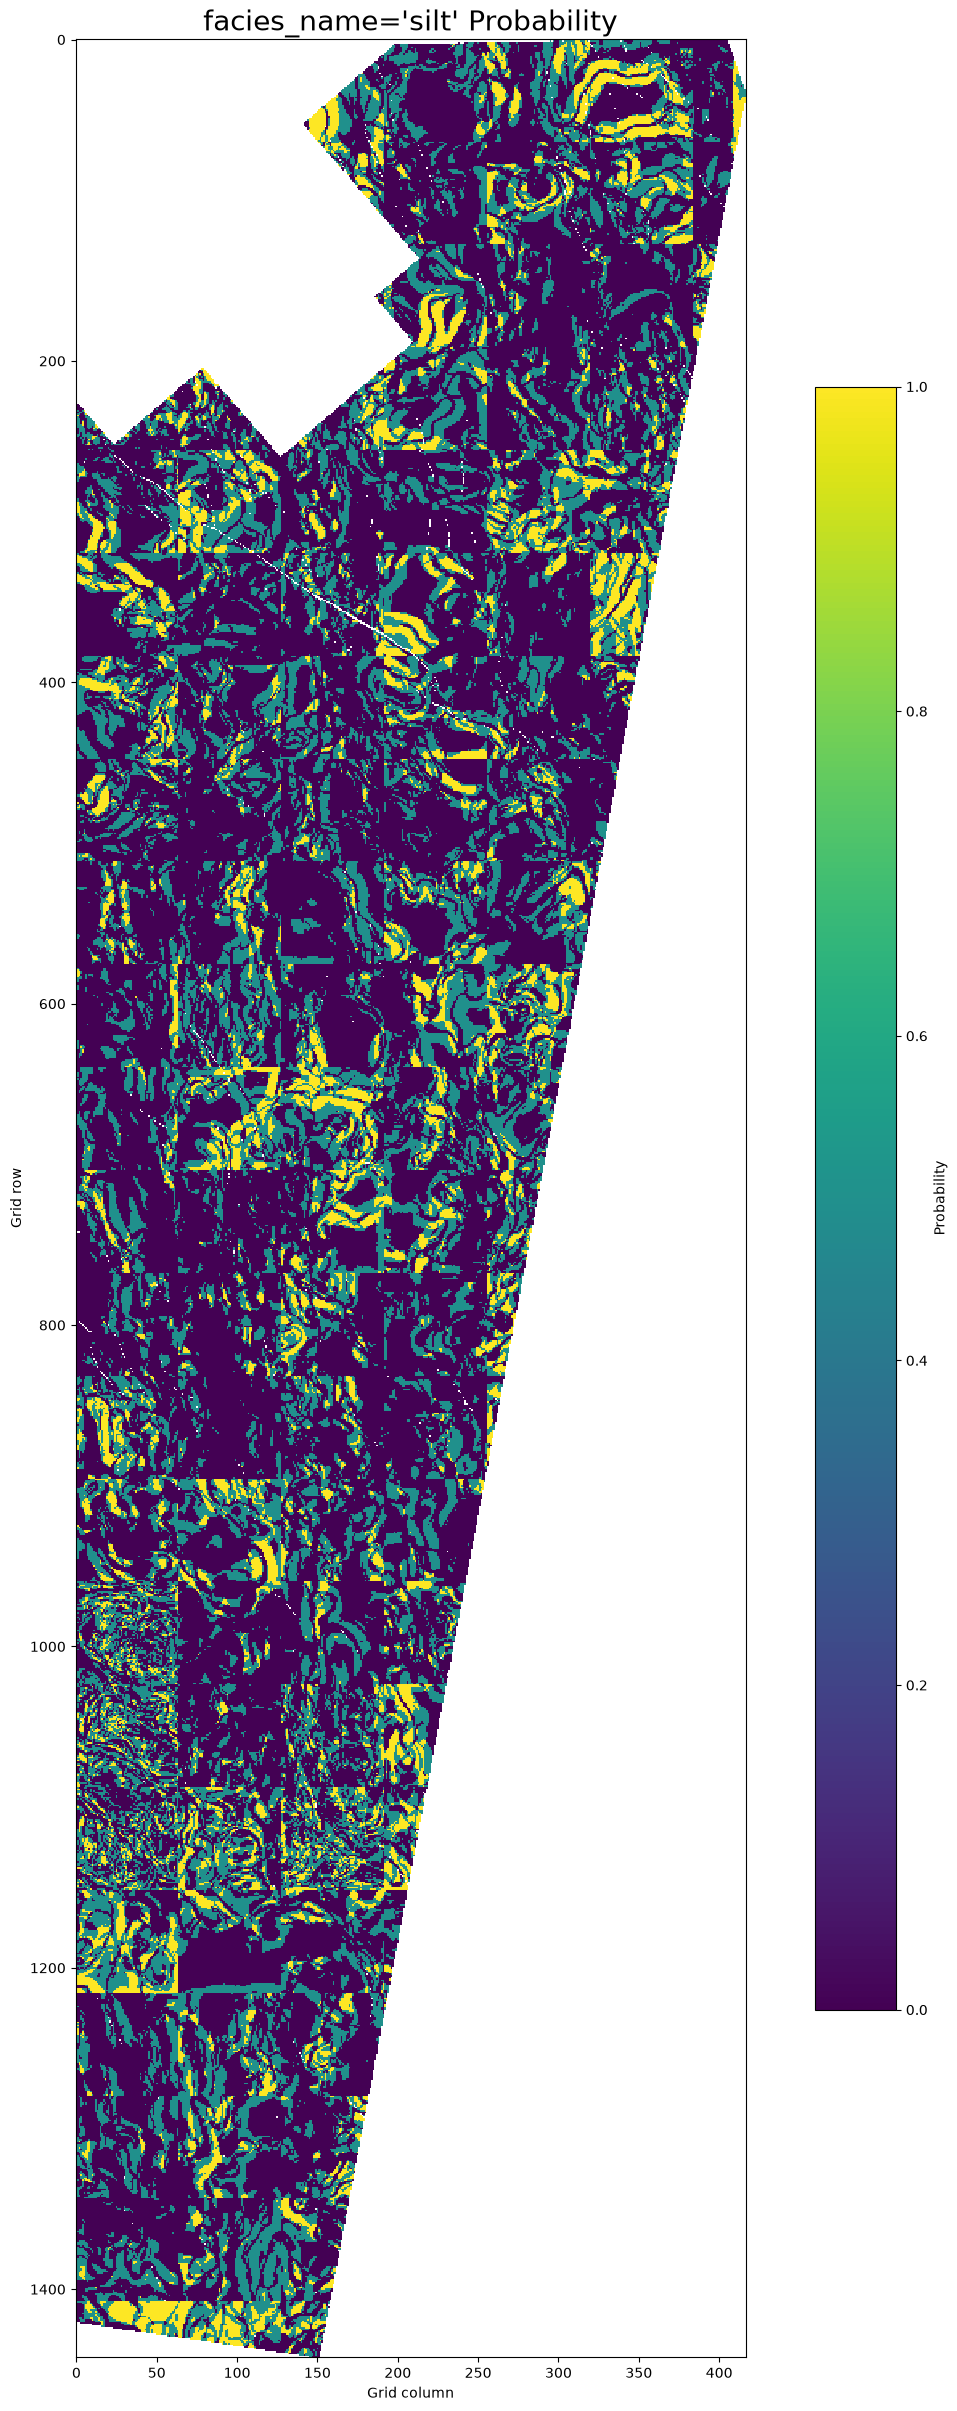

In [2]:
# 2. Plot RMS, most-likely facies, and separate per-facies probabilities
FACIES_COLORS = ["#3E3E3E", "#E6B422", "#8FBBD9"]
facies_cmap = ListedColormap(FACIES_COLORS)
PLOT_SIZE = (16, 24)

facies_names = {
    0: "shale",
    1: "sand",
    2: "silt",
}

fig, axis = plt.subplots(figsize=PLOT_SIZE, constrained_layout=True)
rms_image = axis.imshow(rms_grid, cmap="rainbow", aspect="equal", vmax=1000)
axis.set_title(f"h05 RMS (subsampled x{SUBSAMPLE_FACTOR})", fontsize=20)
axis.set_xlabel("Grid column")
axis.set_ylabel("Grid row")
fig.colorbar(rms_image, ax=axis, label="RMS amplitude", shrink=0.7)
plt.show()

fig, axis = plt.subplots(figsize=PLOT_SIZE, constrained_layout=True)
facies_image = axis.imshow(
    np.ma.masked_where(~covered, most_likely),
    cmap=facies_cmap,
    vmin=-0.5,
    vmax=2.5,
    aspect="equal",
    interpolation="nearest",
)
axis.set_title("Most Likely Facies", fontsize=20)
axis.set_xlabel("Grid column")
axis.set_ylabel("Grid row")
colorbar = fig.colorbar(facies_image, ax=axis, ticks=range(len(facies_names)), shrink=0.7)
colorbar.ax.set_yticklabels([facies_names[i] for i in range(len(facies_names))])
plt.show()

for code, facies_name in facies_names.items():
    fig, axis = plt.subplots(figsize=PLOT_SIZE, constrained_layout=True)
    probability_image = axis.imshow(
        np.ma.masked_where(~covered, probabilities[code]),
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        aspect="equal",
        interpolation="nearest",
    )
    axis.set_title(f"{facies_name=} Probability", fontsize=20)
    axis.set_xlabel("Grid column")
    axis.set_ylabel("Grid row")
    fig.colorbar(probability_image, ax=axis, label="Probability", shrink=0.7)
    plt.show()